IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


#  Semaine 3 : algorithme du perceptron de Rosenblatt

<font size="+1" color="RED">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

*Double-cliquer ici et insérer les noms et prénoms de votre binôme*

<font color="RED" size="+1">**[Q]**</font> **Renommer ce notebook**

Tout en haut de cette page, cliquer sur <tt>tme-03</tt> et rajouter à la suite de <tt>tme-03</tt> les noms des membres du binômes séparés par un tiret.

<font color="RED" size="+1">IMPORTANT: soumission de votre fichier final</font>

**Nom à donner au fichier à poster** : *tme-03-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme
- ne pas compresser ou faire une archive: il faut rendre le fichier ipython tel quel, éventuellement, si vous avez d'autres fichiers vous les rendez séparément.

**Echancier pour la soumission de votre compte-rendu:**
- le compte-rendu d'une séance doit être remis obligatoirement <font color="RED">avant la séance suivante</font>.

**Le compte-rendu est soumis sur la page Moodle.**

Les imports suivants seront généralement nécessaires:

In [30]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2

# - - - - - - - - - - - - - - - - - -
# Information sur l'environnent utilisé ici:
print("Version python et des librairies:")
print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Version python et des librairies:
	Python  3.14.0 (main, Oct  7 2025, 09:34:52) [Clang 17.0.0 (clang-1700.3.19.1)]
	pandas:  3.0.0
	numpy:  2.4.2
	matplotlib:  3.10.8


## Retour sur le sujet du TME 2

In [31]:
# ------------------------ REPRENDRE ICI LES FONCTIONS SUIVANTES DU TME 2:
# genere_dataset_uniform:
def genere_dataset_uniform(d, nc, binf=-1, bsup=1):
    """ int * int * float^2 -> tuple[array, array]
        Hyp: n est pair
        d: nombre de dimensions de la description
        nc: nombre d'exemples de chaque classe
        les valeurs générées uniformément sont dans [binf,bsup]
    """
    
    # #####################
    # COMPLETER ICI (et enlever la ligne suivante qui lève une exception)
    # #####################
    tuple_1 = np.random.uniform(binf, bsup, (2*nc, d))
    tuple_2 = np.array([-1 for i in range(0,nc)] + [+1 for i in range(0,nc)])
    return (tuple_1, tuple_2)
    #raise NotImplementedError("Please Implement this method")

# genere_dataset_gaussian:
def genere_dataset_gaussian(positive_center, positive_sigma, negative_center, negative_sigma, nc):
    """ les valeurs générées suivent une loi normale
        rend un tuple (data_desc, data_labels)
    """
    #####################################
    # COMPLETER ICI (puis enlever la ligne suivante)
    #####################################
    pos = np.random.multivariate_normal(positive_center, positive_sigma, nc)
    neg = np.random.multivariate_normal(negative_center, negative_sigma, nc)
    data_desc = np.vstack((neg, pos))
    data_label = np.array([-1 for i in range(0,nc)] + [+1 for i in range(0,nc)])
    return (data_desc, data_label)
    #raise NotImplementedError("Please Implement this method")

# plot2DSet:
def plot2DSet(desc, labels, nom_dataset="Dataset", avec_grid=True):    
    desc = np.asarray(desc)
    labels = np.asarray(labels)
    idx_neg = (labels == -1)
    idx_pos = (labels == 1)
    desc_neg = desc[idx_neg]
    desc_pos = desc[idx_pos]
    plt.scatter(desc_neg[:,0], desc_neg[:,1], marker='o', color="red", label="classe -1")
    plt.scatter(desc_pos[:,0], desc_pos[:,1], marker='x', color="blue", label="classe +1") 
    plt.title(nom_dataset)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(avec_grid)
    plt.show()

# plot_frontiere:
def plot_frontiere(desc_set, label_set, classifier, step=30):
    """ desc_set * label_set * Classifier * int -> NoneType
        Remarque: le 4e argument est optionnel et donne la "résolution" du tracé: plus il est important
        et plus le tracé de la frontière sera précis.        
        Cette fonction affiche la frontière de décision associée au classifieur
    """
    mmax=desc_set.max(0)
    mmin=desc_set.min(0)
    x1grid,x2grid=np.meshgrid(np.linspace(mmin[0],mmax[0],step),np.linspace(mmin[1],mmax[1],step))
    grid=np.hstack((x1grid.reshape(x1grid.size,1),x2grid.reshape(x2grid.size,1)))
    
    # calcul de la prediction pour chaque point de la grille
    res=np.array([classifier.predict(grid[i,:]) for i in range(len(grid)) ])
    res=res.reshape(x1grid.shape)
    # tracer des frontieres
    # colors[0] est la couleur des -1 et colors[1] est la couleur des +1
    plt.contourf(x1grid,x2grid,res,colors=["darksalmon","skyblue"],levels=[-1000,0,1000])



Taille du dataset généré : (200, 2) exemples
Les 5 premiers exemples :
<class 'numpy.ndarray'> 
 [[-0.14221264 -0.43921547]
 [ 0.58305124  0.05380205]
 [-1.87766937 -1.93782504]
 [ 0.01503527 -0.48621405]
 [ 0.01504769  2.85273149]]


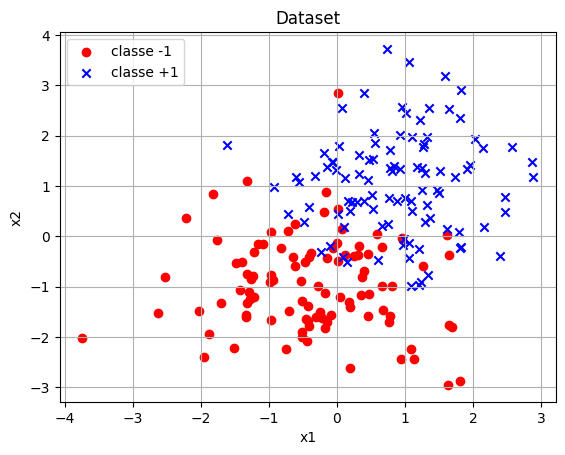

In [32]:
# Exemple d'utilisation:
np.random.seed(42)   # on prend 42 comme graine

# On génère un dataset de 200 exemples en dimension 2:
data_gauss_desc, data_gauss_label = genere_dataset_gaussian(np.array([1,1]),np.array([[1,0],[0,1]]),np.array([-0.5,-1]),np.array([[1,0],[0,1]]),100)

print("Taille du dataset généré :", np.shape(data_gauss_desc), "exemples")

print("Les 5 premiers exemples :")
print(type(data_gauss_desc), '\n', data_gauss_desc[0:5,:])

# Affichage des exemples générés:
plot2DSet(data_gauss_desc, data_gauss_label)

## Remarque sur la génération de nombres aléatoires

Dans nos notebooks, on utilise la commande `np.random.seed(42) ` comme graine pour le générateur de nombres aléatoires car cela vous permet de comparer vos réponses aux nôtres. Mais cela n'est utilisé que pour la mise au point, une fois que vos fonctions / instructions sont mises au point, il est **important** que vous réalisiez d'autres expérimentations en faisant varier la graine, voire sans utiliser l'instruction `seed` avant de lancer vos fonctions.

## Evaluation d'un algorithme d'apprentissage

Un algorithme d'apprentissage permet de construire ou mettre au point un modèle de prédiction qui pourra donner (on dit aussi prédire), pour tout nouvel exemple, le label à associer à cet exemple.
Si on connaît par ailleurs le vrai label de l'exemple, le label trouvé par le modèle est comparé à ce vrai label et on peut donc déterminer si le modèle s'est trompé ou s'il a raison.

Soit $f$ un modèle. Etant donné un ensemble $\bf X$ contenant $n$ exemples, et $Y$ l'ensemble des labels associés à ces exemples, tels que pour tout $\bf x_i \in \bf X$, $y_i$ est le label correspondant.

Un exemple $\bf x_i$ tel que $f(\bf x_i) = y_i$ est dit *bien classé par $f$*.
Un exemple $\bf x_i$ tel que $f(\bf x_i) \not= y_i$ est dit *mal classé par $f$*.

#### Taux de bonne classification
Le **taux de bonne classification** (ou *accuracy*) obtenu par $f$ pour les données de l'ensemble $\bf X$ est: 
$$\frac{n_{bc}}{n}$$

avec $n_{bc}$ le nombre d'exemples $\bf x_i$ de $\bf X$ bien classés par $f$, c'est-à-dire pour lesquels $f(\bf x_i) = y_i$.


#### Performance d'un modèle
Un modèle appris grâce à un algorithme d'apprentissage peut être évalué sur 2 aspects:
- sa capacité à rendre compte des données qui ont servi à le mettre au point : on évalue cela en mesurant son taux de bonne classification (ou *accuracy*) sur des données d'apprentissage.
- sa capacité à **généraliser** ce qu'il a appris sur des données qu'il ne connaît pas : on évalue cela en mesurant son taux de bonne classification (ou *accuracy*)  sur des données différentes de celles utilisées en apprentissage, on parle de **données test**.

Ainsi, un modèle appris qui est très performant sur les données d'apprentissage, mais qui a performances très faibles en prédiction sur d'autres données n'est souvent pas très intéressant. La capacité de généraliser est ce que l'on recherche en premier lieu pour un bon modèle.

#### Ensemble d'apprentissage et ensemble de test
Pour évaluer un modèle appris $f$, on a donc besoin de 2 ensembles d'exemples pour lesquels on connaît le label:
- la **base d'apprentissage** (ou *training set*): il est composé d'un ensemble d'exemples $\bf X$ associé à un ensemble de labels correspondant $Y$. La base d'apprentissage est l'ensemble que l'on utilise pour mettre au point le modèle lors de la phase *train*.
    - pour le knn, la base d'apprentissage correspond à l'ensemble que l'on mémorise.
    - pour le perceptron, la base d'apprentissage est utilisée pour trouver le bon paramétrage du modèle.
- la **base de test** (ou *test set*): il est composé d'un ensemble d'exemples $\bf X_t$ associé à un ensemble de labels correspondant $Y_t$. Les exemples de la base de test ne sont pas utilisés durant la phase d'apprentissage. Ces exemples ne sont utilisés que pour calculer un taux de bonne classification du modèle.

#### Evaluation d'un modèle
Pour évaluer correctement un modèle, on doit fournir 2 taux de bonne classification(ou *accuracy*) :
- le taux de bonne classification sur la base d'apprentissage;
- le taux de bonne classification sur une base de test.


## Construction d'une base d'apprentissage et d'une base de test

Dans la pratique, on possède généralement une seule base d'exemples (cf. données USPS du TME 2) à partir de laquelle on construit les 2 bases nécessaires.
Soit $\bf X$ un ensemble de $n$ exemples et $Y$ l'ensemble des labels associés (ie. tout $\bf x_i \in \bf X$ a pour label $y_i \in Y$, pour $i=1,.., n$).

- la base d'apprentissage $(\bf X_{train}, Y_{train})$ est construite en sélectionnant aléatoirement $n_+$ exemples de label $+1$ et $n_-$ exemples de labels $-1$ (généralement $n_+ = n_-$).
- la base de test $(\bf X_{test}, Y_{test})$ est construire en prenant tous les exemples de $\bf X$ qui n'ont pas été sélectionnés dans $\bf X_{train}$.


<font color="RED" size="+1">**[Q]**</font>  Ecrire la fonction `genere_train_test` qui, étant donné deux `ndarray`, un donnant des descriptions et l'autre les labels correspondants, rend 2 tuples:
- le premier tuple correspond à la base d'apprentissage $(\bf X_{train}, Y_{train})$
- le deuxième tuple correspond à la base de test $(\bf X_{test}, Y_{test})$

Pour écrire cette fonction, on peut utiliser la fonction `random.sample` de la librairie `random` (attention, cette librairie contient des fonctions différentes des fonctions random de la librairie numpy que l'on a utilisé jusqu'à présent).
La fonction `random.sample` prend 2 arguments: une liste $L$ et un entier $k$, et elle rend $k$ éléments de $L$ choisis aléatoirement (sans remise).

In [33]:
# Exemple d'utilisation de la fonction random.sample:

import random
random.seed(42)  # pour avoir les mêmes tirages

# Choix aléatoire de 5 éléments de la liste:
random.sample([i for i in range(0,100)], 5)

[81, 14, 3, 94, 35]

In [34]:
# A quoi correspond le résultat de cette commande ?:

L = random.sample([i for i in range(0,data_gauss_desc.shape[0])],10)
data_gauss_desc[L]

array([[-1.50601738, -2.21418861],
       [ 0.80547881, -0.97899616],
       [ 0.94127329, -2.43586215],
       [ 1.01300189,  2.45353408],
       [ 1.6221562 ,  0.03246526],
       [-0.23695071, -0.32045661],
       [ 0.73534317,  3.72016917],
       [ 1.09176078, -0.98756891],
       [-1.70029641, -1.33450124],
       [ 0.65728548,  0.19772273]])

In [35]:
# A quoi correspond le résultat de cette commande ?:
data_gauss_desc[data_gauss_label == -1].shape

(100, 2)

Ainsi, si la liste L contient les indices de tous les exemples d'une base d'exemples, il devient facile de sélectionner un sous-ensemble de ces exemples en tirant aléatoirement leurs indices par cette fonction.

In [36]:
# ------------------------ A COMPLETER
def genere_train_test(desc_set, label_set, n_pos, n_neg):
    """ permet de générer une base d'apprentissage et une base de test
        desc_set: array avec des descriptions
        label_set: array avec les labels correspondants
        n_pos: nombre d'exemples de label +1 à mettre dans la base d'apprentissage
        n_neg: nombre d'exemples de label -1 à mettre dans la base d'apprentissage
        Hypothèses: 
           - desc_set et label_set ont le même nombre de lignes)
           - n_pos et n_neg, ainsi que leur somme, sont inférieurs à n (le nombre d'exemples dans desc_set)
    """
    import numpy as np

def genere_train_test(desc_set, label_set, n_pos, n_neg):
    """ permet de générer une base d'apprentissage et une base de test
    """
    # 1. Séparation des indices par classe
    indices_pos = np.where(label_set == 1)[0]
    indices_neg = np.where(label_set == -1)[0]
    
    # 2. Mélange aléatoire des indices de chaque classe
    rng = np.random.default_rng()
    rng.shuffle(indices_pos)
    rng.shuffle(indices_neg)
    
    # 3. Sélection des indices pour le TRAIN
    train_idx_pos = indices_pos[:n_pos]
    train_idx_neg = indices_neg[:n_neg]
    
    # 4. Sélection des indices pour le TEST (le reste des données)
    test_idx_pos = indices_pos[n_pos:]
    test_idx_neg = indices_neg[n_neg:]
    
    # 5. Regroupement des indices (Train ensemble et Test ensemble)
    train_indices = np.concatenate([train_idx_pos, train_idx_neg])
    test_indices = np.concatenate([test_idx_pos, test_idx_neg])
    
    # Optionnel: on peut mélanger les indices finaux pour ne pas avoir 
    # tous les +1 suivis de tous les -1
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)
    
    # 6. Création des bases finales en utilisant le slicing par indices
    train_desc = desc_set[train_indices]
    train_label = label_set[train_indices]
    
    test_desc = desc_set[test_indices]
    test_label = label_set[test_indices]
    
    return ((train_desc, train_label), (test_desc, test_label))

    

<font color="RED" size="+1">**[Q]**</font>  Utiliser la fonction précédente pour générer une base d'apprentissage et une base de test à partir des données aléatoires gaussiennes générées plus haut. La base d'apprentissage contiendra 75 exemples de la classe +1 et 75 exemples de la classe -1.

In [37]:
random.seed(42)
(train_desc, train_label), (test_desc, test_label) = genere_train_test(data_gauss_desc, data_gauss_label,75,75)

print("Base d'apprentissage: ",train_desc.shape, " et ", len(train_label)," labels")
print("Base de test: ",test_desc.shape, " et ", len(test_label)," labels")

Base d'apprentissage:  (150, 2)  et  150  labels
Base de test:  (50, 2)  et  50  labels


<font color="RED" size="+1">**[Q]**</font> En vous inspirant de la fonction `plot2DSet`, écrire une nouvelle fonction, `plot2DTrainTestSet` qui prend en argument 4 arrays: 2 arrays qui représentent une base d'apprentissage (description et label), et 2 arrays qui représentent une base de test, et qui affiche une représentation graphique de ce jeu de données en distinguant par des couleurs différentes les données d'apprentissage et celles de test.

In [38]:
def plot2DTrainTestSet(d_train,l_train, d_test,l_test, nom_dataset= "Dataset", avec_grid=True):    
    """ array * array array * array * str * bool-> affichage
        nom_dataset (str): nom du dataset pour la légende
        avec_grid (bool) : True si on veut afficher la grille, False sinon
        la fonction doit utiliser les couleurs suivantes:
        - pour les données d'apprentissage : la couleur 'red' pour la classe -1 et 'blue' pour la +1
        - pour les données de test : la couleur 'jaune' pour la classe -1 et 'verte' pour la +1
    """

    ###############################################
    #################### COMPLETER 
    ###############################################

    desc_train = np.asarray(d_train)
    desc_test = np.asarray(d_test)
    labels_train = np.asarray(l_train)
    labels_test = np.asarray(l_test)
    
    idx_neg_test = (l_test == -1)
    idx_pos_test = (l_test == 1)
    desc_neg_test = d_test[idx_neg_test]
    desc_pos_test = d_test[idx_pos_test]

    idx_neg_train = (l_train == -1)
    idx_pos_train = (l_train == 1)
    desc_neg_train = d_train[idx_neg_train]
    desc_pos_train = d_train[idx_pos_train]
    plt.scatter(desc_neg_test[:,0], desc_neg_test[:,1], marker='o', color="yellow", label="classe -1 test")
    plt.scatter(desc_pos_test[:,0], desc_pos_test[:,1], marker='x', color="green", label="classe +1 test") 
    plt.scatter(desc_neg_train[:,0], desc_neg_train[:,1], marker='o', color="red", label="classe -1")
    plt.scatter(desc_pos_train[:,0], desc_pos_train[:,1], marker='x', color="blue", label="classe +1") 
    plt.title(nom_dataset)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(avec_grid)
    plt.show()



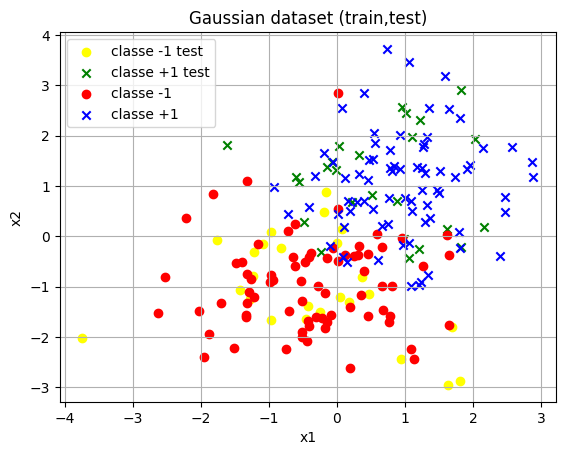

In [39]:
plot2DTrainTestSet(train_desc, train_label,test_desc, test_label, nom_dataset="Gaussian dataset (train,test)")

## Perceptron de Rosenblatt

De la même façon que nous avons défini des classes pour le classifieur par k-ppv et le classifieur linéaire aléatoire, nous allons maintenant définir une nouvelle classe de classifieurs pour implémenter un nouvel algorithme d'apprentissage : le **perceptron de Rosenblatt**.

<div class="alert alert-block alert-info">

**Apprentissage d'un perceptron**<BR>
L'apprentissage d'un perceptron consiste à partir d'une base de données étiquetées $\mathbf X \in \mathbb R^{n\times d}, \mathbf Y\in \{-1,1\}^n$ de fournir un **vecteur de paramètres** optimisés, de dimension $d$, $\mathbf w\in \mathbb R^{d}$.

Le perceptron est représenté par le vecteur $\mathbf w$ et on utilise comme paramètre pour le mettre au point un *learning rate* $\epsilon \in [0,1]$ qui est défini à la création du classifieur (paramètre du constructeur).
    
En termes algorithmiques, l'apprentissage est itératif:
1. Initialisation de $\mathbf w$: il y a 2 façons possibles (à choisir), $\mathbf w$ est initialisé soit comme vecteur nul (toutes ses composantes à 0), soit aléatoirement. 
    
    *Attention, si l'initialisation est aléatoire, **les valeurs doivent être très petites** et également réparties entre valeurs positives et négatives pour ne pas biaiser l'algorithme. On pourra dans ce cas pour générer chaque composante de $\mathbf w$:
   1) générer aléatoirement une valeur $v$ dans $[0,1[$,
   2) la transformer en $2v-1$ pour qu'elle soit dans $[-1,1[$,
   3) la multiplier par un nombre réel positif petit (par exemple $0.001$) pour obtenir une valeur très petite.
1. Optimisation stochastique grâce à la base d'apprentissage $\mathbf X$:
    1. Choisir aléatoirement un exemple $\mathbf x_i$ de $\mathbf X$
    1. Calculer le score $\hat y_i$ fourni par le perceptron par $\hat y_i = \mathbf x_i \cdot \mathbf w$ en utilisant le vecteur $\mathbf w$ courant
        - le label associé $\hat y_i^*$ obtenu en prenant le signe de $\hat y_i$ correspond à la prédiction (+1 ou -1) faite par le perceptron pour $\mathbf x_i$.
    1. Evaluer l'erreur de prédiction pour $\mathbf x_i$, sachant que le label à trouver doit être $y_i$ (donné dans $\mathbf Y$). 
        1. Si *pas d'erreur*, pas de correction à faire
        1. Si *erreur*, corriger $\mathbf w$ par : 
        $$\mathbf w \leftarrow \mathbf w + \epsilon y_i \mathbf x_i$$
       
    1. Arrêter lorsqu'il y a convergence:
        1. Convergence = aucun ou peu de changements sur $\mathbf w$ pendant $n$ itérations. Pour évaluer le changement, on calcule la norme de la valeur absolue de la différence terme à terme entre $w$ (vecteur avant l'étape 2) et $w'$ (vecteur après l'étape 2). Il y a convergence quand cette valeur descend en dessous d'un seuil de convergence (qui est un réel positif non nul).
        1. Remarque : on peut fixer un nombre d'itérations maximum au bout desquelles l'algorithme doit s'arrêter pour ne pas se coincer dans une boucle infinie.

**Classification / Prédiction / Inférence avec un perceptron**<BR>
L'inférence est linéaire: 
    $$\hat y_i =  \mathbf x_i \cdot \mathbf w , \qquad \hat y_i^* =\text{sign}(\hat y_i) \in \{-1,1\}$$
   
   $\hat y_i$ correspond au score fourni par le perceptron (valeur réelle donc) et $y_i^*$ correspond à la prédiction (+1 ou -1).
    
<br/>
<b>Remarque:</b> attention à ne pas confondre l'évaluation linéaire à valeur réelle et le signe qui permet de mettre notre estimation dans le même univers que les étiquettes d'origine.
    
    
</div>    

<font color="RED" size="+1">**[Q]**</font> En héritant de la classe `Classifier` (qu'il faut donc récupérer pour la mettre dans ce notebook), écrire la classe `ClassifierPerceptron` qui implémente l'algorithme du perceptron de Rosenblatt vu en cours. 

Lors de l'initialisation, dans la méthode `__init__`, deux paramètres seront fournis:
- le learning_rate (`epsilon`) du perceptron (par défaut, il sera mis à $0.01$). 
- un argument booléen de nom `init` qui vaut `True` (par défaut) ou `False` et qui donne le mode souhaité d'initialisation du perceptron: soit en mettant les poids $w_1, \ldots, w_d$ à 0 (valeur `True`), soit en les initialisant aléatoirement par des valeurs très petites (valeur `False`) comme expliqué dans le descriptif ci-dessus.

Pour l'apprentissage du perceptron, on écrit les 2 fonctions suivantes.

La fonction `train_step` réalise **une unique itération de tous les exemples** du dataset d'apprentissage $\mathbf X$ en prenant ces exemples un par un, dans un ordre aléatoire (cf. shuffle expliqué ci-après). Cet ordre doit être tiré aléatoirement au moment de l'exécution de la fonction `train_step` (à chaque lancement de `train_step`, l'ordre devra donc être différent). Dans cette fonction, pour chaque exemple $\mathbf x$, on applique l'algorithme expliqué dans le cadre précédent.

La fonction `train` implémente l'algorithme complet de l'apprentissage itératif du perceptron jusqu'à sa convergence, elle appelle donc la fonction `train_step` autant de fois que nécessaire. Après chaque appel, si la convergence est atteinte, l'algorithme s'arrête, sinon, il se poursuit par un nouvel appel. La fonction `train` prend en argument, en plus du dataset, un entier `nb_max` qui donne le nombre d'itérations maximal à réaliser, et un réel `seuil` qui donne le seuil de convergence à atteindre. Cette fonction rend la liste des **valeurs des différences** rencontrées.

*Remarque*: quelques fonctions utiles :
- la fonction `np.zeros` qui prend en argument un entier. Par exemple, tester `np.zeros(10)`.
- la fonction `np.random.shuffle` qui prend une liste de valeurs en arguments et la modifie (par effet de bord) en réordonnant aléatoirement les valeurs.
- pour copier un `np.array`, il est nécessaire d'utiliser la méthode `copy()` qui réalise une copie profonde. Par exemple, `B = A.copy()` pour copier le `np.array A` dans la variable `B`.

**IMPORTANT**: dans les boîtes ci-dessous, on utilise toujours la même graine (seed) de génération de nombres aléatoires, ceci pour vous permettre de mettre au point vos fonctions, une fois qu'elles sont mises au point, il vous faut alors réaliser des expérimentations **sans utiliser de graine**.

In [40]:
# Par exemple :

np.random.seed(42)   # on prend 42 comme graine

V_ex =[i for i in range(0,10)]
print("V_ex avant shuffle: ",V_ex)
np.random.shuffle(V_ex)  # REMARQUE: cette fonction modifie V_ex
print("V_ex après shuffle: ",V_ex)

V_ex avant shuffle:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
V_ex après shuffle:  [8, 1, 5, 0, 7, 2, 9, 4, 3, 6]


In [41]:
# ------------------------ A COMPLETER :

# Recopier ici la classe Classifier (complète) du TME 2
from abc import ABC, abstractmethod

class Classifier(ABC):
    """ Classe (abstraite) pour représenter un classifieur
        Attention: cette classe est ne doit pas être instanciée.
    """
    __nombre_crees: int = 0  # Variable de classe pour compter le nombre de classifiers créés
    
    def __init__(self, input_dimension):
        """ Constructeur de Classifier
            Argument:
                - intput_dimension (int) : dimension de la description des exemples
            Hypothèse : input_dimension > 0
        """
        Classifier.__nombre_crees += 1
        self.__ident = Classifier.__nombre_crees  # identifiant du classifieur (unique)
        self.__dimension = input_dimension
        
    def get_dimension(self):
        """ Accesseur de la variable __dimension 
        """
        return self.__dimension
        
    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet 
        """
        return f'Classifier #{self.__ident} (d{self.__dimension})'
        
    @abstractmethod
    def train(self, desc_set, label_set) -> None:
        """ Permet d'entrainer le modele sur l'ensemble donné
            desc_set: array avec des descriptions
            label_set: array avec les labels correspondants
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """        
        pass

    @abstractmethod
    def score(self,x) -> float:
        """ rend le score de prédiction sur x (valeur réelle)
            x: une description
        """
        pass
    
    @abstractmethod
    def predict(self, x) -> int:
        """ rend la prediction sur x (soit -1 ou soit +1)
            x: une description
        """
        pass

    def accuracy(self, desc_set, label_set) -> float:
        """ rend le taux d'exemples bien classés dans le dataset
            desc_set: array avec des descriptions
            label_set: array avec les labels correspondants
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """
        corr = 0
        nb_donnees = len(desc_set)
        for i in range(nb_donnees):
            if label_set[i] == self.predict(desc_set[i]):
                corr += 1
            
        return corr / nb_donnees


In [42]:
# ------------------------ A COMPLETER : DEFINITION DU CLASSIFIEUR PERCEPTRON

class ClassifierPerceptron(Classifier):
    """ Perceptron de Rosenblatt
    """
    def __init__(self, input_dimension, learning_rate=0.01, init=True, verbose=False ):
        """ Constructeur de Classifier
            Argument:
                - input_dimension (int) : dimension de la description des exemples (>0)
                - learning_rate (par défaut 0.01): epsilon
                - init est le mode d'initialisation de w: 
                    - si True (par défaut): initialisation à 0 de w,
                    - si False : initialisation par tirage aléatoire de valeurs petites
                - verbose: pour dire si on veut afficher la valeur d'initialisation
        """
        super().__init__(input_dimension)  # Appel du constructeur de la classe mère
        ########### A COMPLETER ###################
        self.__learning = learning_rate
        if init:
            self.__w = np.zeros(input_dimension)
        else:
            self.__w  = (2 * np.random.rand(input_dimension) - 1) * 0.001
        ###########################################
        if verbose:
            print(f"{super().__str__()}: initialisation (learning rate= {self.__learning}) w= {self.__w}")

        
    def train_step(self, desc_set, label_set):
        """ Réalise une unique itération sur tous les exemples du dataset
            donné en prenant les exemples aléatoirement.
            Arguments:
                - desc_set: array avec des descriptions
                - label_set: array avec les labels correspondants
        """  
        rng = np.random.default_rng()
        idx = list(range(len(label_set)))
        rng.shuffle(idx)

        for i in idx:
            x_i = desc_set[i]
            y_i = label_set[i]
            y = self.score(x_i)
            if (y_i * y) <= 0: 
               self.__w = self.__w + self.__learning * y_i * x_i  

     
    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet 
        """
        return f'ClassifierPerceptron (d{self.get_dimension()})'

    def train(self, desc_set, label_set, nb_max=100, seuil=0.001,verbose=False):
        """ Apprentissage itératif du perceptron sur le dataset donné.
            Arguments:
                - desc_set: array avec des descriptions
                - label_set: array avec les labels correspondants
                - nb_max (par défaut: 100) : nombre d'itérations maximale
                - seuil (par défaut: 0.001) : seuil de convergence
                - verbose (par défaut: False): affichage de messages d'information
            Retour: la fonction rend une liste
                - liste des valeurs de norme de différences
        """ 
        result_list = list()       
        for i in range(nb_max):
            w_old = self.__w.copy()
            self.train_step(desc_set, label_set)
            w_new = self.__w
            dif = np.linalg.norm(np.abs(w_new - w_old))
            result_list.append(dif)
            if dif < seuil:
                return result_list
        return result_list    
            
    def score(self,x):
        """ rend le score de prédiction sur x (valeur réelle)
            x: une description
        """
        return np.dot(self.__w, x)

    
    def predict(self, x):
        """ rend la prediction sur x (soit -1 ou soit +1)
            x: une description
        """
        return 1 if (self.score(x)) >= 0 else -1

## Validation de l'algorithme

<font color="RED" size="+1">**[Q]**</font>  Afin de vérifier le bon fonctionnement de l'algorithme, nous allons procéder à plusieurs tests:

1. Expérimentation avec les gaussiennes jouets définies dans le TME 2
    1. Vérifier l'impact du réglage de l'initialisation (normalement, il n'y a pas trop d'impact sur un problème aussi simple)
    1. Vérifier l'impact du réglage de epsilon (impact énorme: ca diverge très rapidement!!)
    1. En jouant sur la génération des données, tester votre perceptron dans le cas facile (nuages des deux classes bien séparés) puis dans le cas plus difficile où les classes ne sont plus séparables linéairement.

1. Expérimentation avec les données USPS (cf. TME 2)
    1. Nous travaillerons uniquement dans le cas binaire. Prendre les 1 vs 2 (cas facile) puis les 3 vs 6 ou 9 (cas nettement plus dur)
    
1. Penser à faire le parallèle avec le temps pour prédire avec les k-ppv de la semaine précédente
    
**Note:** il faut évidemment multiplier les boites et ne pas tout faire au même endroit.

### Test sur des gaussiennes jouets

Pour mettre au point votre perceptron, vous pouvez utiliser les données fournies dans le répertoire `data` qui ont été générées par selon 2 gaussiennes et séparées en données d'apprentissage et de test. 

Base d'apprentissage: (150, 2)	Base de test: (50, 2)


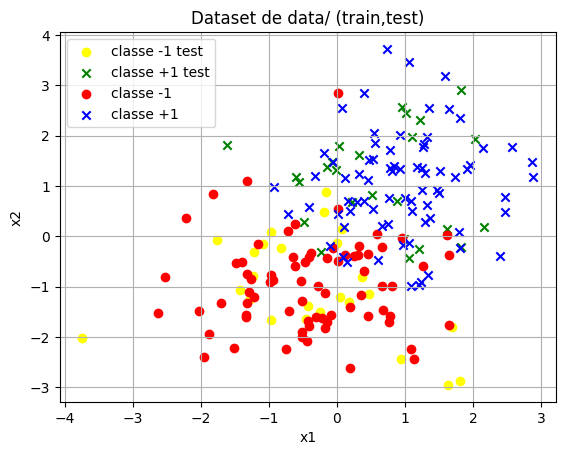

In [ ]:
# Chargement des données qui se trouvent dans le répertoire data/
data = pd.read_csv("data/data_train.csv", header=None)
data_train = np.array(data[[0,1]])
label_train  = np.array(data[2])
data = pd.read_csv("data/data_test.csv", header=None)
data_test = np.array(data[[0,1]])
label_test  = np.array(data[2])

print(f"Base d'apprentissage: {data_train.shape}\tBase de test: {data_test.shape}")
plot2DTrainTestSet(train_desc, train_label,test_desc, test_label, nom_dataset="Dataset de data/ (train,test)")

#### Apprentissage pas à pas et variation d'accuracy

0.8933333333333333
0.9
0.9
0.9066666666666666
0.9066666666666666
0.8933333333333333
0.9
0.8733333333333333
0.9133333333333333
0.82
0.9066666666666666
0.9066666666666666
0.9066666666666666
0.9
0.9
0.8866666666666667
0.8733333333333333
0.8333333333333334
0.9066666666666666
0.9066666666666666
0.8733333333333333
0.9
0.9
0.9
0.9133333333333333
0.88
0.9
0.9066666666666666
0.9066666666666666
0.9066666666666666
0.8933333333333333
0.92
0.9
0.9
0.9066666666666666
0.8466666666666667
0.9
0.9066666666666666
0.9
0.9066666666666666
0.8933333333333333
0.9
0.8933333333333333
0.8933333333333333
0.9133333333333333
0.9
0.9
0.9
0.92
0.9133333333333333
0.9066666666666666
0.9
0.88
0.9066666666666666
0.9066666666666666
0.9
0.9
0.9
0.46
0.9066666666666666
0.9066666666666666
0.9066666666666666
0.9133333333333333
0.9066666666666666
0.9066666666666666
0.9066666666666666
0.9
0.86
0.9066666666666666
0.9066666666666666
0.9
0.9133333333333333
0.9
0.9066666666666666
0.9066666666666666
0.88
0.9066666666666666
0.9066666

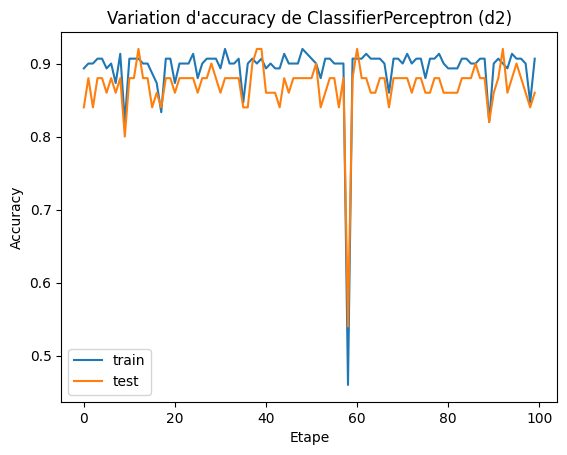

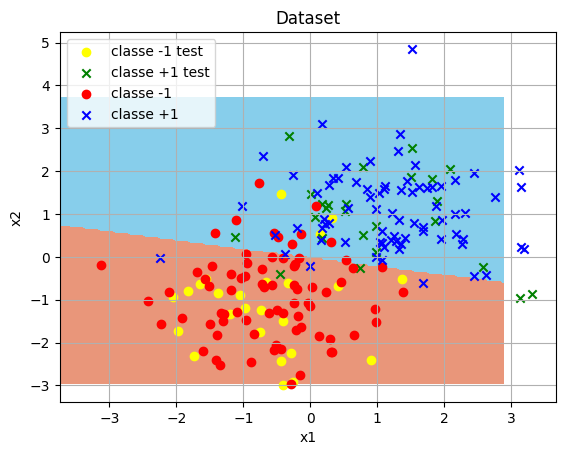

Accuracy finale (train):  0.9066666666666666
Accuracy finale (test) :  0.86
Accuracy2 finale (train):  0.9066666666666666
Accuracy2 finale (test) :  0.86


In [44]:
# ------------------------ COMPLETER LES INSTRUCTIONS DANS CETTE BOITE 
np.random.seed(42)   # on prend 42 comme graine
# Création d'un perceptron avec initialisation à 0 et le learning_rate ci-dessous:
learning_rate = 0.01
n_features = data_train.shape[1]
perceptron1 = ClassifierPerceptron(n_features, learning_rate, True, False)

# -----
# Apprentissage pas à pas du perceptron et mémorisation de l'accuracy à chaque étape:
# Listes qui vont servir à mémoriser les accuracy du perceptron à chaque étape:
train_acc = []
test_acc = []

# Réalisation de N itérations de train_step
N = 100
for i in range(0,N):
    # [*** A COMPLETER ***]
    perceptron1.train_step(data_train, label_train)
    a = perceptron1.accuracy(data_train, label_train)
    print(a)
    train_acc.append(perceptron1.accuracy(data_train, label_train))
    test_acc.append(perceptron1.accuracy(data_test, label_test))

# -----
# Traçage de la courbe des variations d'accuracy
plt.title(f"Variation d'accuracy de {perceptron1}")
courbe_train = plt.plot(train_acc, label='train')
courbe_test = plt.plot(test_acc, label='test')
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape")
plt.show()

# -----
# Affichage de la frontière de séparation des classes (en prenant tous les exemples de la base)
plot_frontiere(data_gauss_desc,data_gauss_label,perceptron1,step=150)
plot2DTrainTestSet(data_train,label_train,data_test,label_test)

print("Accuracy finale (train): ", train_acc[-1])
print("Accuracy finale (test) : ", test_acc[-1])

print("Accuracy2 finale (train): ",  train_acc[-1])
print("Accuracy2 finale (test) : ",  test_acc[-1])

### Apprentissage et affichage de la convergence

Pour tester la fonction  `train`, vous pouvez utiliser les données fournies dans répertoire `data` qui représentent une base d'apprentissage et une base de test générées à partir de données gaussiennes.

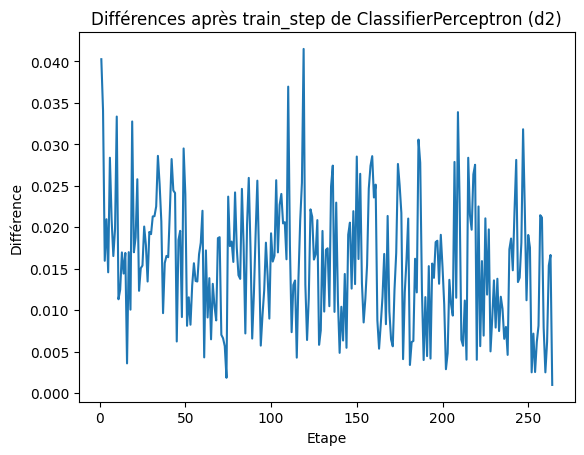

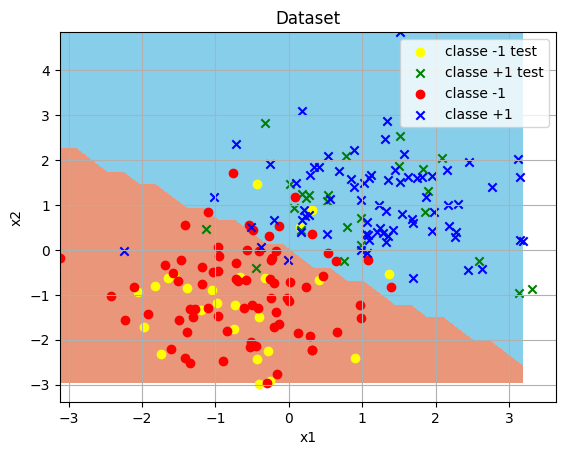

Accuracy finale (train):  0.9
Accuracy finale (test) :  0.88


In [ ]:
# ------------------------ COMPLETER LES INSTRUCTIONS DANS CETTE BOITE 
np.random.seed(42)   # on prend 42 comme graine
# Création d'un perceptron avec initialisation à 0 et le learning_rate ci-dessous:
learning_rate = 0.01
perceptron2 = ClassifierPerceptron(data_train.shape[1], learning_rate, init=True)

# Apprentissage du perceptron jusqu'à convergence : on fixe une borne max à 1000
les_variations = perceptron2.train(data_train, label_train, nb_max=1000, verbose=True)

# Traçage de la courbe des variations
plt.title(f"Différences après train_step de {perceptron2}")
plt.plot(range(1,len(les_variations)+1),les_variations)  
plt.ylabel('Différence')
plt.xlabel("Etape")
plt.show()

# Affichage de la frontière de séparation des classes
plot_frontiere(data_train, label_train, perceptron2)
plot2DTrainTestSet(data_train, label_train, data_test, label_test)

print("Accuracy finale (train): ",  perceptron2.accuracy(data_train, label_train))
print("Accuracy finale (test) : ", perceptron2.accuracy(data_test, label_test))

### Initialisation aléatoire et convergence

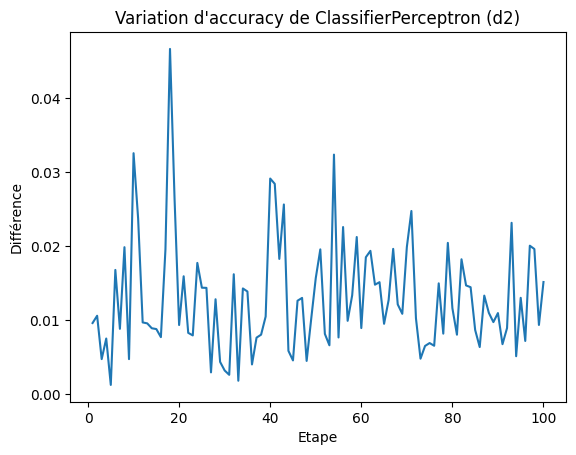

Accuracy finale (train):  0.8533333333333334
Accuracy finale (test) :  0.86


In [46]:
# ------------------------ COMPLETER LES INSTRUCTIONS DANS CETTE BOITE 

np.random.seed(42)   # on prend 42 comme graine

# Création d'un perceptron avec initialisation aléatoire et le learning_rate ci-dessous:
learning_rate = 0.01
perceptron3 = ClassifierPerceptron(data_train.shape[1], learning_rate, init=False)

# Apprentissage du perceptron
les_variations = perceptron3.train(data_train, label_train)

# Traçage de la courbe des variations
plt.title(f"Variation d'accuracy de {perceptron3}")
plt.plot(range(1,len(les_variations)+1),les_variations)  
plt.ylabel('Différence')
plt.xlabel("Etape")
plt.show()

print("Accuracy finale (train): ",  perceptron3.accuracy(data_train, label_train))
print("Accuracy finale (test) : ", perceptron3.accuracy(data_test, label_test))

### Impact du learning rate

<font color="RED" size="+1">[Q]</font> Tester différentes valeurs de learning rate et regarder les résultats en termes de convergence.

Par exemple, que se passe-t-il quand le learning rate est mis à 0.1?

Classifier #4 (d2): initialisation (learning rate= 0.1) w= [0. 0.]


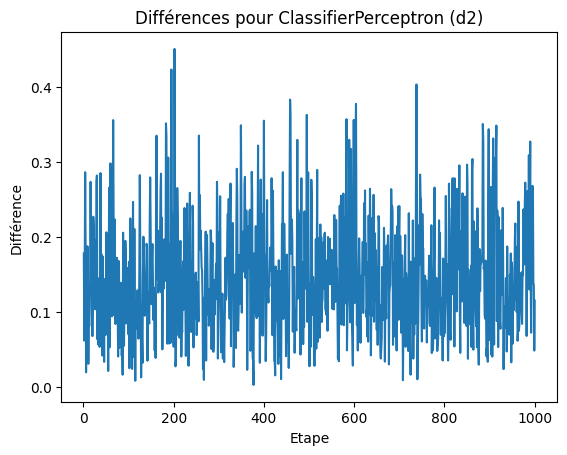

Accuracy finale (train):  0.9
Accuracy finale (test) :  0.88


In [47]:
# Par exemple : 

# ------------------------ COMPLETER LES INSTRUCTIONS DANS CETTE BOITE 

np.random.seed(42)   # on prend 42 comme graine

# Création d'un perceptron avec initialisation aléatoire et le learning_rate ci-dessous:
learning_rate = 0.1
perceptron4 = ClassifierPerceptron(data_train.shape[1], learning_rate, init=True, verbose=True)

# Apprentissage du perceptron
les_variations = perceptron4.train(data_train, label_train, nb_max=1000, verbose=True)

# Traçage de la courbe des variations
plt.title(f"Différences pour {perceptron4}")
plt.plot(range(1,len(les_variations)+1),les_variations)  
plt.ylabel('Différence')
plt.xlabel("Etape")
plt.show()

print("Accuracy finale (train): ",  perceptron4.accuracy(data_train, label_train))
print("Accuracy finale (test) : ", perceptron4.accuracy(data_test, label_test))

In [48]:
# Analyse de l'impact du learning rate:
# Avec un learning rate plus élevé (0.1), on observe que l'algorithme a du mal à converger :
# - Différences : fortes oscillations.
# - MaJ des poids trop importantes à chaque étape : empêche convergence

<font color="RED" size="+1">[Q]</font> Quand le learning rate est mis à 0.01, en utilisant le paramètre `nb_max`, trouver combien d'itérations sont nécessaires pour que l'algorithme converge.

Nb iterations réalisées: 403


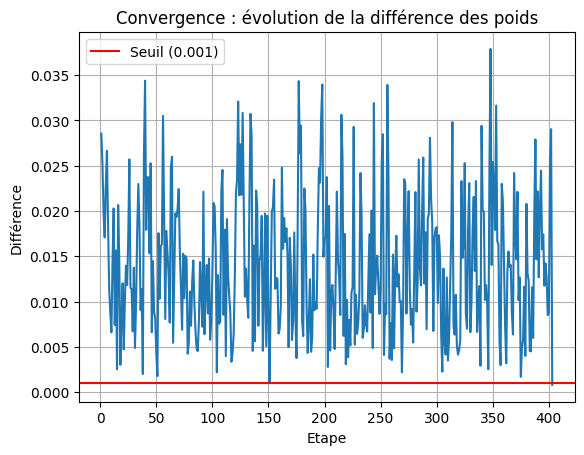

Accuracy finale (train):  0.9
Accuracy finale (test) :  0.9


In [49]:
np.random.seed(42)   # on prend 42 comme graine

# ------------------------ COMPLETER LES INSTRUCTIONS DANS CETTE BOITE 

# ############################# A COMPLETER POUR FOURNIR LE NOMBRE D'ITERATIONS NECESSAIRES

# Création d'un perceptron avec initialisation aléatoire et le learning_rate ci-dessous:
learning_rate = 0.01
perceptron_conv = ClassifierPerceptron(data_train.shape[1], learning_rate, init=False)

# Apprentissage du perceptron
# On met nb_max assez grand pour être sûr de converger
variations = perceptron_conv.train(data_train, label_train, nb_max=1000)

print(f"Nb iterations réalisées: {len(variations)}")

# Traçage de la courbe des variations
plt.plot(range(1,len(variations)+1),variations)  
plt.ylabel('Différence')
plt.xlabel("Etape")
plt.title("Convergence : évolution de la différence des poids") 
plt.grid(True) 
# On ajoute une ligne horizontale rouge marquant le seuil de convergence 0.001
plt.axhline(y=0.001, color='r', linestyle='-', label="Seuil (0.001)")
plt.legend()
plt.show()

print("Accuracy finale (train): ", perceptron_conv.accuracy(data_train, label_train))
print("Accuracy finale (test) : ", perceptron_conv.accuracy(data_test, label_test))

### Expérimentations supplémentaires

<font color="RED" size="+1">[Q]</font> Réaliser plusieurs expérimentations en utilisant vos fonctions `genere_dataset_gaussian` et `genere_train_test`:
- faire varier la taille du dataset (500, 1000, 2000 exemples)
- faire varier le learning rate
- comparer les 2 méthodes d'initialisation du vecteur de poids
- comparer les résultats en accuracy avec ceux obtenus avec un KNN (en testant différentes valeurs de $k$)
  

In [50]:
class ClassifierKNN(Classifier):
    """ Classe pour représenter un classifieur par K plus proches voisins.
        Cette classe hérite de la classe Classifier
    """
    def __init__(self, input_dimension, k):
        """ Constructeur de Classifier
            Argument:
                - intput_dimension (int) : dimension d'entrée des exemples
                - k (int) : nombre de voisins à considérer
            Hypothèse : input_dimension > 0
        """
        super().__init__(input_dimension)  # Appel du constructeur de la classe mère
        self.__k= k
        # les 2 variables suivantes seront utilisées dans la méthode train()
        self.__desc_set= None   
        self.__labels_set= None

    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet 
        """

        return f"ClassifierKNN k={self.__k} (d{self.get_dimension()})"

    def train(self, desc_set, label_set) -> None:
        """ Permet d'entrainer le modele sur l'ensemble donné
            desc_set: array avec des descriptions
            label_set: array avec les labels correspondants
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """        
        self.__desc_set = desc_set
        self.__labels_set = label_set

    def score(self,x) -> float:
        """ rend la proportion de +1 parmi les k ppv de x (valeur réelle)
            x: une description : un array
        """

        distances = np.linalg.norm((self.__desc_set - x), axis=1)
        k_near_id = np.argsort(distances)[:self.__k]
        labels = self.__labels_set[k_near_id]

        p = np.sum((labels+1)/2)/self.__k
        
        return 2*(p-0.5)

    def predict(self, x) -> int:
        """ rend la prediction sur x (-1 ou +1)
            x: une description : un array
        """

        if (self.score(x) > 0):
            return 1
        return -1




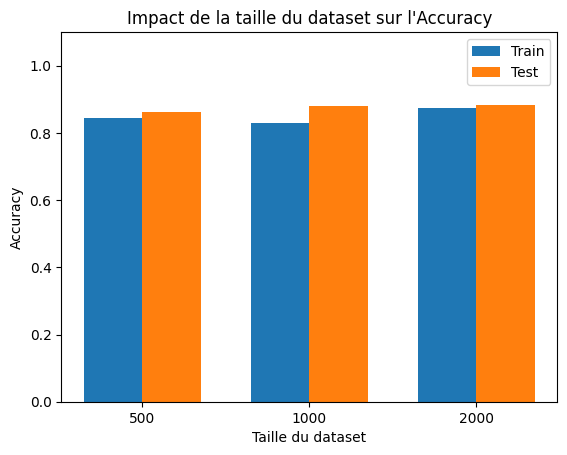

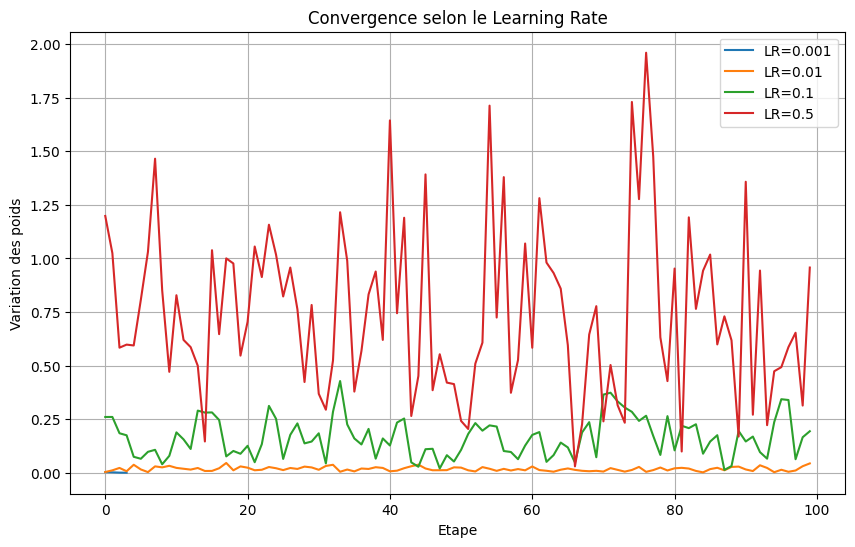

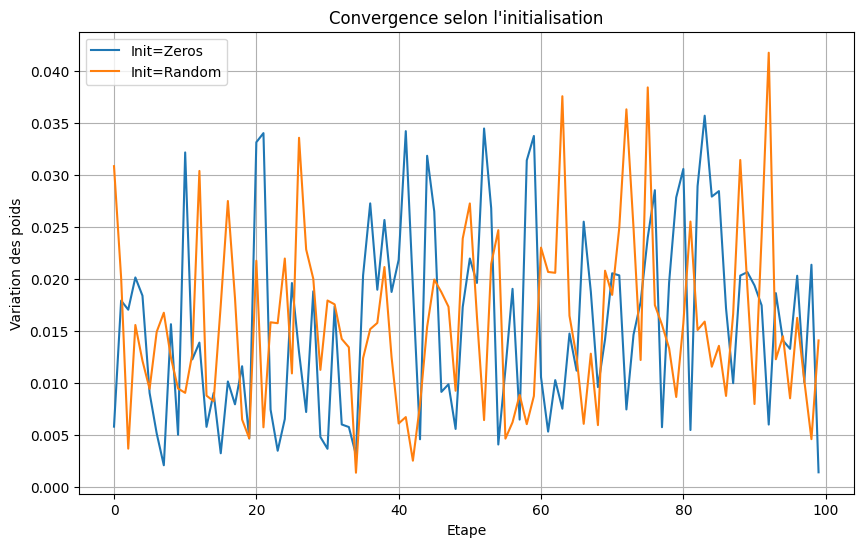

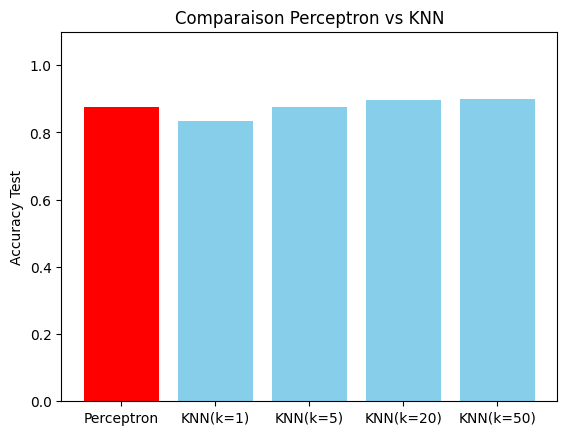

In [54]:
datasets_sizes = [500, 1000, 2000]
accuracies_train = []
accuracies_test = []

for size in datasets_sizes:
    d_desc, d_label = genere_dataset_gaussian(np.array([1,1]),np.array([[1,0],[0,1]]),np.array([-0.5,-1]),np.array([[1,0],[0,1]]),size)
    (d_train, l_train), (d_test, l_test) = genere_train_test(d_desc, d_label, int(size*0.25), int(size*0.25))
    
    perc = ClassifierPerceptron(2, learning_rate=0.01, init=True)
    perc.train(d_train, l_train, nb_max=100)
    
    accuracies_train.append(perc.accuracy(d_train, l_train))
    accuracies_test.append(perc.accuracy(d_test, l_test))

plt.figure()
x = range(len(datasets_sizes))
width = 0.35
plt.bar([i - width/2 for i in x], accuracies_train, width, label='Train')
plt.bar([i + width/2 for i in x], accuracies_test, width, label='Test')
plt.xticks(x, datasets_sizes)
plt.xlabel("Taille du dataset")
plt.ylabel("Accuracy")
plt.title("Impact de la taille du dataset sur l'Accuracy")
plt.legend()
plt.ylim(0, 1.1)
plt.show()

learning_rates_test = [0.001, 0.01, 0.1, 0.5]
d_desc, d_label = genere_dataset_gaussian(np.array([1,1]),np.array([[1,0],[0,1]]),np.array([-0.5,-1]),np.array([[1,0],[0,1]]), 1000)
(d_train, l_train), (d_test, l_test) = genere_train_test(d_desc, d_label, 250, 250)

plt.figure(figsize=(10, 6))
for lr in learning_rates_test:
    perc = ClassifierPerceptron(2, learning_rate=lr, init=False)
    vars = perc.train(d_train, l_train, nb_max=100)
    plt.plot(vars, label=f"LR={lr}")

plt.xlabel("Etape")
plt.ylabel("Variation des poids")
plt.title("Convergence selon le Learning Rate")
plt.legend()
plt.grid()
plt.show()

inits = [True, False]
init_names = ["Zeros", "Random"]

plt.figure(figsize=(10, 6))
for i, init_val in enumerate(inits):
    perc = ClassifierPerceptron(2, learning_rate=0.01, init=init_val)
    vars = perc.train(d_train, l_train, nb_max=100)
    plt.plot(vars, label=f"Init={init_names[i]}")

plt.xlabel("Etape")
plt.ylabel("Variation des poids")
plt.title("Convergence selon l'initialisation")
plt.legend()
plt.grid()
plt.show()

ks = [1, 5, 20, 50]
accs_knn = []
k_labels = []

perc = ClassifierPerceptron(2, learning_rate=0.01, init=True)
perc.train(d_train, l_train)
acc_perc = perc.accuracy(d_test, l_test)

for k in ks:
    knn = ClassifierKNN(2, k)
    knn.train(d_train, l_train)
    accs_knn.append(knn.accuracy(d_test, l_test))
    k_labels.append(f"KNN(k={k})")

plt.figure()
labels = ["Perceptron"] + k_labels
values = [acc_perc] + accs_knn
colors = ['red'] + ['skyblue']*len(ks)

plt.bar(labels, values, color=colors)
plt.ylabel("Accuracy Test")
plt.title(f"Comparaison Perceptron vs KNN")
plt.ylim(0, 1.1)
plt.show()

## Cas difficiles

<font color="RED" size="+1">[Q]</font> Afin de tester des cas plus difficiles (c'est-à-dire non séparables linéairement), écrire la fonction `createXOR` qui permet de générer le jeu de données ci-dessous. Cette fonction prend 2 arguments, un nombre de points $n$ et un réel positif $\sigma$ donnant la variance sur chaque dimension et permet de jouer sur la dispersion des nuages et donc sur la séparation des 4 nuages.

Il s'agit de générer des points dans deux classes mais selon 4 gaussiennes.

<img src="xor.png" width=300px>



In [57]:
# ------------------------ COMPLETER LES INSTRUCTIONS DANS CETTE BOITE 
def create_XOR(n, var):
    """ int * float -> tuple[ndarray, ndarray]
        Hyp: n et var sont positifs
        n: nombre de points voulus
        var: variance sur chaque dimension
    """
    sigma = np.sqrt(var)
    n_par_nuag = n // 4

    gaus = np.random.normal(0, sigma, (n, 2))
    
    #nuage avec coord (1,1)
    gaus[0:n_par_nuag, 0] += 1
    gaus[0:n_par_nuag, 1] += 1
    
    #(-1, -1)
    gaus[n_par_nuag:2*n_par_nuag, 0] -= 1
    gaus[n_par_nuag:2*n_par_nuag, 1] -= 1
    
    # (1, -1)
    gaus[2*n_par_nuag:3*n_par_nuag, 0] += 1
    gaus[2*n_par_nuag:3*n_par_nuag, 1] -= 1
    
    #Центр (-1, 1)
    gaus[3*n_par_nuag:, 0] -= 1
    gaus[3*n_par_nuag:, 1] += 1
    

    labels = np.ones(n)
    labels[2*n_par_nuag:] = -1
    
    return gaus, labels
    

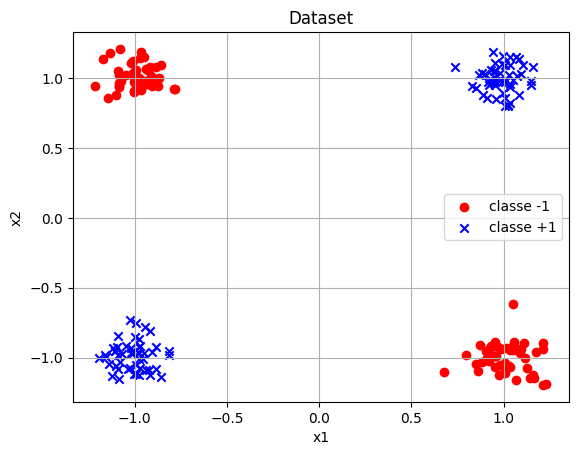

In [59]:
# une fois le fichier d'outils mis à jour, vous devez pouvoir faire:

np.random.seed(42)   # on prend 42 comme graine

# Génération d'un dataset avec 200 points:
data_xor, label_xor = create_XOR(200,0.01)
plot2DSet(data_xor, label_xor)

<font color="RED" size="+1">[Q]</font> Appliquer l'algorithme du perceptron sur ces données et constater (avec quelques affichages de performances et tracés de frontières de décision) que ça ne marche pas!

Classifier #41 (d2): initialisation (learning rate= 0.01) w= [0. 0.]
Accuracy: 50.0%


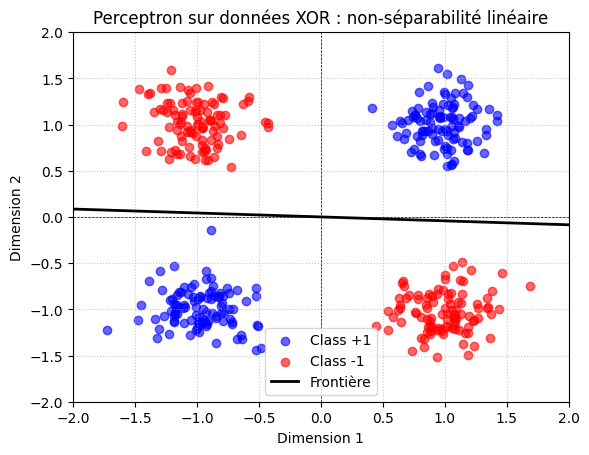

In [67]:
np.random.seed(42)   # on prend 42 comme graine

# Création d'un perceptron
perceptron_xor = ClassifierPerceptron(2,0.01,verbose=True)

# ------------------------ A COMPLETER :
n_points = 400
variance = 0.05
x_xor, y_xor = create_XOR(n_points, variance)
train = perceptron_xor.train(x_xor, y_xor, nb_max=100, seuil=0.001)

print(f"Accuracy: {perceptron_xor.accuracy(x_xor, y_xor) * 100}%")

plt.scatter(x_xor[y_xor == 1, 0], x_xor[y_xor == 1, 1], color='blue', label='Class +1', alpha=0.6)
plt.scatter(x_xor[y_xor == -1, 0], x_xor[y_xor == -1, 1], color='red', label='Class -1', alpha=0.6)

w = perceptron_xor._ClassifierPerceptron__w 
if w[1] != 0:
    x_axis = np.linspace(-2, 2, 100)
    y_axis = -(w[0] / w[1]) * x_axis
    plt.plot(x_axis, y_axis, color='black', lw=2, label='Frontière')

plt.title("Perceptron sur données XOR : non-séparabilité linéaire")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()




## Expérimentations

Compléter ce notebook par des expérimentations sur le Perceptron, par exemple :
1. Test sur les données USPS (cf. TME 2)
    1. Pour réduire la place disque prise par la base USPS, commencer par faire un lien symbolique avec la commande 
    
        `ln -s ../tme-02/data/ .` 
    
       lancée depuis un terminal, en vous plaçant dans votre répertoire `tme-03`.
    1. Nous travaillerons uniquement dans le cas binaire. Prendre les 1 vs 2 (cas facile) puis les 3 vs 6 ou 9 (cas nettement plus dur)
    
1. Comparer les temps de classification avec les k-ppv de la semaine précédente
